In [1]:
import torch
from torch import nn
import numpy as np

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
import zipfile
from pathlib import Path

data_path = Path("product demand/")

if data_path.is_dir():
    print(f"{data_path} directory already exists, skiping dowload..")
else:
    print(f"{data_path} doesn't exist, creating one...")
    data_path.mkdir(parents=True, exist_ok=True)

#Unzip
with zipfile.ZipFile("archive.zip", "r")as zip_ref:
    print("Unzipping data...")
    zip_ref.extractall(data_path)
    

product demand directory already exists, skiping dowload..
Unzipping data...


In [4]:
import pandas as pd
df = pd.read_csv("product demand/Historical Product Demand.csv", parse_dates=["Date"])
df['Order_Demand'] = pd.to_numeric(df['Order_Demand'], errors='coerce')
df = df[df['Order_Demand'] >= 0].dropna(subset=['Order_Demand', 'Date'])
df = df.sort_values(['Product_Code', "Date"]).reset_index(drop=True)

In [5]:
grouped = df.groupby("Product_Code")["Order_Demand"]

df["lag_1"] = grouped.shift(1)
df["lag_2"] = grouped.shift(2)
df["lag_3"] = grouped.shift(3)
df["roll_mean_3"] = grouped.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
df["roll_mean_7"] = grouped.shift(1).rolling(7).mean().reset_index(level=0, drop=True)
df["roll_std_3"] = grouped.shift(1).rolling(3).std().reset_index(level=0, drop=True)

In [6]:
df = df.dropna().reset_index(drop=True)

In [7]:
df = df.sort_values("Date").reset_index(drop=True)

In [8]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,lag_1,lag_2,lag_3,roll_mean_3,roll_mean_7,roll_std_3
0,Product_0982,Whse_A,Category_028,2011-12-09,1000.0,200.0,4500.0,100.0,1600.000000,1392.857143,2511.971337
1,Product_0980,Whse_A,Category_028,2011-12-12,800.0,200.0,300.0,2000.0,833.333333,1114.285714,1011.599394
2,Product_0980,Whse_A,Category_028,2011-12-13,100.0,800.0,200.0,300.0,433.333333,657.142857,321.455025
3,Product_0981,Whse_A,Category_028,2011-12-15,1000.0,600.0,1000.0,1500.0,1033.333333,1150.000000,450.924975
4,Product_0981,Whse_A,Category_028,2011-12-15,3000.0,400.0,1000.0,600.0,666.666667,1285.714286,305.505046


In [9]:
print(f"Date range: {df['Date'].min()} : {df['Date'].max()}\n")

Date range: 2011-12-09 00:00:00 : 2017-01-09 00:00:00



In [10]:
df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year

df = df.drop(["Date"], axis=1)

In [11]:
df.head()

,Product_Code,Warehouse,Product_Category,Order_Demand,lag_1,lag_2,lag_3,roll_mean_3,roll_mean_7,roll_std_3,day_of_week,month,year
0,Product_0982,Whse_A,Category_028,1000.0,200.0,4500.0,100.0,1600.000000,1392.857143,2511.971337,4,12,2011
1,Product_0980,Whse_A,Category_028,800.0,200.0,300.0,2000.0,833.333333,1114.285714,1011.599394,0,12,2011
2,Product_0980,Whse_A,Category_028,100.0,800.0,200.0,300.0,433.333333,657.142857,321.455025,1,12,2011
3,Product_0981,Whse_A,Category_028,1000.0,600.0,1000.0,1500.0,1033.333333,1150.000000,450.924975,3,12,2011
4,Product_0981,Whse_A,Category_028,3000.0,400.0,1000.0,600.0,666.666667,1285.714286,305.505046,3,12,2011


In [12]:
print(len(df.Warehouse.unique()))
print(len(df.Product_Code.unique()))
print(len(df.Product_Category.unique()))

4
2138
33


In [13]:
df = pd.get_dummies(df, columns=['Warehouse'], drop_first=True) 
df.head()

,Product_Code,Product_Category,Order_Demand,lag_1,lag_2,lag_3,roll_mean_3,roll_mean_7,roll_std_3,day_of_week,month,year,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S
0,Product_0982,Category_028,1000.0,200.0,4500.0,100.0,1600.000000,1392.857143,2511.971337,4,12,2011,False,False,False
1,Product_0980,Category_028,800.0,200.0,300.0,2000.0,833.333333,1114.285714,1011.599394,0,12,2011,False,False,False
2,Product_0980,Category_028,100.0,800.0,200.0,300.0,433.333333,657.142857,321.455025,1,12,2011,False,False,False
3,Product_0981,Category_028,1000.0,600.0,1000.0,1500.0,1033.333333,1150.000000,450.924975,3,12,2011,False,False,False
4,Product_0981,Category_028,3000.0,400.0,1000.0,600.0,666.666667,1285.714286,305.505046,3,12,2011,False,False,False


In [14]:
df['Product_Code'] = df['Product_Code'].str.removeprefix('Product_').astype(int)
df['Product_Category'] = df['Product_Category'].str.removeprefix('Category_').astype(int)
df.head()

,Product_Code,Product_Category,Order_Demand,lag_1,lag_2,lag_3,roll_mean_3,roll_mean_7,roll_std_3,day_of_week,month,year,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S
0,982,28,1000.0,200.0,4500.0,100.0,1600.000000,1392.857143,2511.971337,4,12,2011,False,False,False
1,980,28,800.0,200.0,300.0,2000.0,833.333333,1114.285714,1011.599394,0,12,2011,False,False,False
2,980,28,100.0,800.0,200.0,300.0,433.333333,657.142857,321.455025,1,12,2011,False,False,False
3,981,28,1000.0,600.0,1000.0,1500.0,1033.333333,1150.000000,450.924975,3,12,2011,False,False,False
4,981,28,3000.0,400.0,1000.0,600.0,666.666667,1285.714286,305.505046,3,12,2011,False,False,False


In [15]:
df.dtypes

Product_Code          int64
Product_Category      int64
Order_Demand        float64
lag_1               float64
lag_2               float64
lag_3               float64
roll_mean_3         float64
roll_mean_7         float64
roll_std_3          float64
day_of_week           int32
month                 int32
year                  int32
Warehouse_Whse_C       bool
Warehouse_Whse_J       bool
Warehouse_Whse_S       bool
dtype: object

In [16]:
df['Order_Demand'] = pd.to_numeric(df['Order_Demand'], errors='coerce')
df = df[df['Order_Demand'] >= 0]
df = df.dropna(subset=['Order_Demand'])
df = df.dropna(subset=['day_of_week', 'month', 'year'])
df = df.reset_index(drop=True)

In [17]:
X = df.drop(["Order_Demand"], axis=1).astype(float).to_numpy()
y = df["Order_Demand"].astype(float).to_numpy()

In [18]:
df.dtypes

Product_Code          int64
Product_Category      int64
Order_Demand        float64
lag_1               float64
lag_2               float64
lag_3               float64
roll_mean_3         float64
roll_mean_7         float64
roll_std_3          float64
day_of_week           int32
month                 int32
year                  int32
Warehouse_Whse_C       bool
Warehouse_Whse_J       bool
Warehouse_Whse_S       bool
dtype: object

In [19]:
from torch.utils.data import TensorDataset, Subset

In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [21]:
le_code = LabelEncoder()
le_cat = LabelEncoder()

In [22]:
df['Product_Code'] = le_code.fit_transform(df["Product_Code"])
df['Product_Category'] = le_cat.fit_transform(df["Product_Category"])

In [23]:
num_codes = len(le_code.classes_)
num_cats = len(le_cat.classes_)

In [24]:
#X_cat = torch.tensor(df[['Product_Code', 'Product_Category']].to_numpy(), dtype=torch.long)
X_cat = df[['Product_Code', 'Product_Category']].to_numpy()
cols_num = ['day_of_week', 'month', 'year', 'Warehouse_Whse_C', 'Warehouse_Whse_J', 'Warehouse_Whse_S',
           'lag_1', 'lag_2', 'lag_3', 'roll_mean_3','roll_mean_7', 'roll_std_3']
X_cont =df[cols_num].astype(float).to_numpy()

In [25]:
split = int(len(y) * 0.8)
X_cat_train, X_cat_test = X_cat[:split], X_cat[split:]
X_cont_train, X_cont_test = X_cont[:split], X_cont[split:]
y_train, y_test = y[:split], y[split:]

In [26]:
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [27]:
lag_cols = ['lag_1', 'lag_2', 'lag_3', 'roll_mean_3','roll_mean_7', 'roll_std_3']
lag_indices = [cols_num.index(c) for c in lag_cols]

X_cont_train[:, lag_indices] = np.log1p(X_cont_train[:, lag_indices])
X_cont_test[:, lag_indices] = np.log1p(X_cont_test[:, lag_indices])

In [28]:
scaler_y = StandardScaler()
scaler_x = StandardScaler()
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)
X_cont_train = scaler_x.fit_transform(X_cont_train)
X_cont_test = scaler_x.transform(X_cont_test)

In [29]:
X_cat_train = torch.tensor(X_cat_train, dtype=torch.long)
X_cat_test = torch.tensor(X_cat_test, dtype=torch.long)

In [30]:
X_cont_train = torch.tensor(X_cont_train, dtype=torch.float32)
X_cont_test = torch.tensor(X_cont_test, dtype=torch.float32)

In [31]:
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [33]:
X_cat_train = X_cat_train.to(device)
X_cat_test = X_cat_test.to(device)
X_cont_train = X_cont_train.to(device)
X_cont_test = X_cont_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

In [34]:
class Model_0(nn.Module):
    def __init__(self, num_codes, num_cats, num_numeric):
        super().__init__()

        self.code_embed = nn.Embedding(num_codes, min(50, (num_codes +1) // 2))
        self.cat_embed = nn.Embedding(num_cats, min(50, (num_cats +1) // 2))
        emb_dim = min(50, (num_codes +1) // 2) + min(50, (num_cats +1) // 2)

        self.fc = nn.Sequential(
            nn.Linear(emb_dim + num_numeric, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, X_cat, X_cont):
        emb_code = self.code_embed(X_cat[:,0])
        emb_cat = self.cat_embed(X_cat[:, 1])

        x = torch.cat([emb_code, emb_cat, X_cont], dim=1)
        return self.fc(x).squeeze(1)

In [35]:
num_numeric = len(cols_num)

In [36]:
model_0 = Model_0(num_codes, num_cats, num_numeric).to(device)

In [37]:
import torch.optim as optim

#loss function and optimizer
loss_fn = nn.MSELoss() #mean square error
optimizer = optim.Adam(model_0.parameters(), lr=0.0001)

In [38]:
for epoch in range(100):
    model_0.train()
    optimizer.zero_grad()

    y_pred = model_0(X_cat_train, X_cont_train)
    loss   = loss_fn(y_pred.squeeze(), y_train.squeeze())

    loss.backward()
    optimizer.step()

    # Validation
    model_0.eval()
    with torch.no_grad():
        y_pred_test = model_0(X_cat_test, X_cont_test)
        test_loss   = loss_fn(y_pred_test.squeeze(), y_test.squeeze())

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1:3d}/100 | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

Epoch   1/100 | Train Loss: 1.2764 | Test Loss: 1.2085
Epoch  11/100 | Train Loss: 1.2150 | Test Loss: 1.1488
Epoch  21/100 | Train Loss: 1.1567 | Test Loss: 1.0922
Epoch  31/100 | Train Loss: 1.1015 | Test Loss: 1.0386
Epoch  41/100 | Train Loss: 1.0495 | Test Loss: 0.9880
Epoch  51/100 | Train Loss: 1.0002 | Test Loss: 0.9403
Epoch  61/100 | Train Loss: 0.9536 | Test Loss: 0.8950
Epoch  71/100 | Train Loss: 0.9093 | Test Loss: 0.8521
Epoch  81/100 | Train Loss: 0.8672 | Test Loss: 0.8114
Epoch  91/100 | Train Loss: 0.8272 | Test Loss: 0.7728


In [39]:
BATCH_SIZE = 8192

In [40]:
train_ds = TensorDataset(X_cat_train, X_cont_train, y_train)
test_ds  = TensorDataset(X_cat_test, X_cont_test, y_test)

In [41]:
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

In [42]:
class Model_1(nn.Module):
    def __init__(self, num_codes: int, num_cats: int, num_numeric: int,
                hidden_dim: int = 64, num_layers: int = 1):
        super().__init__()
        code_dim = min(50, (num_codes + 1) // 2)
        cat_dim = min(50, (num_cats + 1) // 2)
        emb_dim = code_dim + cat_dim

        self.code_embed = nn.Embedding(num_codes, code_dim)
        self.cat_embed = nn.Embedding(num_cats, cat_dim)

        in_features = emb_dim + num_numeric

        self.lstm = nn.LSTM(
            input_size=in_features,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32,1)
        )
    def forward(self, X_cat: torch.Tensor, X_cont: torch.Tensor) -> torch.Tensor:
        emb_code = self.code_embed(X_cat[:, 0])
        emb_cat = self.cat_embed(X_cat[:, 1])
        x = torch.cat([emb_code, emb_cat, X_cont], dim=1)
        x = x.unsqueeze(1)
        lstm_out, (hidden, cell) = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        return self.fc(last_out).squeeze(1)

In [43]:
model_1   = Model_1(num_codes, num_cats, num_numeric).to(device)

In [44]:
loss_fn_1 = nn.HuberLoss(delta=1.0)
optimizer_1 = optim.Adam(model_1.parameters(), lr=0.001, weight_decay=0.0001)

In [45]:
EPOCHS = 100

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_1, mode='min',
                                                 factor=0.2, patience=10)

scaler = torch.amp.GradScaler(device="cuda")

for epoch in range(1, EPOCHS+1):
    model_1.train()
    train_loss_sum = 0.0

    for batch_cat, batch_cont, batch_y in train_loader:
        optimizer_1.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            preds = model_1(batch_cat, batch_cont)
            loss= loss_fn_1(preds.squeeze(), batch_y.squeeze())
        scaler.scale(loss).backward()
        scaler.step(optimizer_1)
        scaler.update()
        train_loss_sum += loss.item() * len(batch_y)
    avg_train_loss = train_loss_sum / len(train_ds)
    scheduler.step(avg_train_loss)

    model_1.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch_cat, batch_cont, batch_y in test_loader:
            preds = model_1(batch_cat, batch_cont)
            val_loss = loss_fn_1(preds.squeeze(), batch_y.squeeze())
            val_loss_sum += val_loss.item() * len(batch_y)
        avg_val_loss = val_loss_sum / len(test_ds)
        scheduler.step(avg_val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_val_loss:.4f}")

Epoch  10/100 Train Loss: 0.1198 | Test Loss: 0.1121
Epoch  20/100 Train Loss: 0.1163 | Test Loss: 0.1094
Epoch  30/100 Train Loss: 0.1157 | Test Loss: 0.1087
Epoch  40/100 Train Loss: 0.1149 | Test Loss: 0.1082
Epoch  50/100 Train Loss: 0.1147 | Test Loss: 0.1082
Epoch  60/100 Train Loss: 0.1147 | Test Loss: 0.1081
Epoch  70/100 Train Loss: 0.1146 | Test Loss: 0.1082
Epoch  80/100 Train Loss: 0.1147 | Test Loss: 0.1082
Epoch  90/100 Train Loss: 0.1146 | Test Loss: 0.1081
Epoch 100/100 Train Loss: 0.1147 | Test Loss: 0.1082


In [46]:
model_1.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for batch_cat, batch_cont, batch_y in test_loader:
        with torch.amp.autocast(device_type='cuda'):
            preds = model_1(batch_cat, batch_cont)
        all_preds.append(preds.squeeze().cpu().numpy())
        all_actuals.append(batch_y.squeeze().cpu().numpy())

all_preds = np.concatenate(all_preds)
all_actuals = np.concatenate(all_actuals)

In [47]:
all_preds_real = scaler_y.inverse_transform(all_preds.astype(np.float64).reshape(-1,1)).flatten()
all_actuals_real = scaler_y.inverse_transform(all_actuals.astype(np.float64).reshape(-1,1)).flatten()
all_preds_real = np.expm1(all_preds_real)
all_actuals_real = np.expm1(all_actuals_real)

In [48]:
N = 20
indices = np.random.choice(len(all_preds_real), size=N, replace=False)

comparison_df = pd.DataFrame({
    "Actual": all_actuals_real[indices].round(1),
    "Predicted": all_preds_real[indices].round(1),
    "Error": (all_actuals_real[indices] - all_preds_real[indices]).round(1)
})
print(comparison_df.to_string(index=False))

 Actual  Predicted   Error
  100.0     2454.7 -2354.7
40000.0     3845.9 36154.1
  300.0      275.0    25.0
  100.0      255.2  -155.2
 1000.0      829.6   170.4
10000.0     4637.0  5363.0
   50.0       12.5    37.5
30000.0    23977.8  6022.2
  100.0      103.6    -3.6
10000.0      920.9  9079.1
20000.0     1394.2 18605.8
    0.0       11.7   -11.7
  100.0      263.6  -163.6
10000.0     7017.9  2982.1
 5100.0      589.2  4510.8
 5000.0     3121.6  1878.4
10000.0     2746.3  7253.7
    2.0        5.8    -3.8
   10.0       12.0    -2.0
 5000.0    13103.5 -8103.5


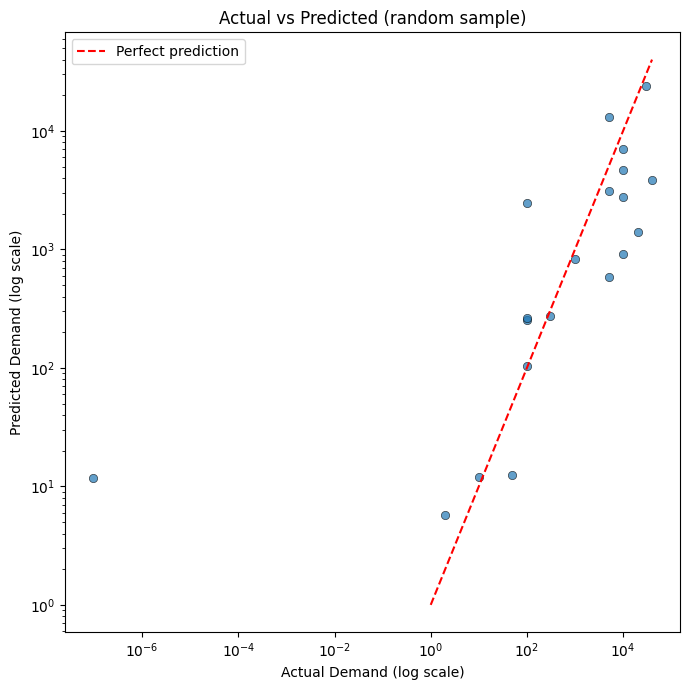

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(all_actuals_real[indices], 
            all_preds_real[indices], 
            alpha=0.7, edgecolors="k", linewidths=0.5)

sample_min = max(min(all_actuals_real[indices].min(), all_preds_real[indices].min()), 1)
sample_max = max(all_actuals_real[indices].max(), all_preds_real[indices].max())

plt.plot([sample_min, sample_max], [sample_min, sample_max], 'r--', label='Perfect prediction')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Actual Demand (log scale)")
plt.ylabel("Predicted Demand (log scale)")
plt.title("Actual vs Predicted (random sample)")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
 def compare_models(model_0, model_1, X_cat_test, X_cont_test, y_test,
                    scaler_y, N=20, seed=56, device="cuda"):
     np.random.seed(seed)
     indices = np.random.choice(len(y_test),size=N, replace=False)
     indices = torch.tensor(indices, device=device)

     model_0.eval()
     with torch.no_grad():
         with torch.amp.autocast(device_type=device):
             preds_0 = model_0(
                 X_cat_test[indices].to(device),
                 X_cont_test[indices].to(device)
             ).cpu().numpy()
             
     model_1.eval()
     with torch.no_grad():
         with torch.amp.autocast(device_type=device):
             preds_1 = model_1(
                 X_cat_test[indices].to(device),
                 X_cont_test[indices].to(device)
             ).cpu().numpy()
             
     actuals = y_test[indices].cpu().numpy()
     def to_real(arr):
        inv = scaler_y.inverse_transform(
            arr.astype(np.float64).reshape(-1,1)).flatten()
        return np.expm1(inv)
     real_actual = np.round(to_real(actuals))
     real_pred_0 = np.round(to_real(preds_0))
     real_pred_1 = np.round(to_real(preds_1))

     df = pd.DataFrame({
        "Actual": real_actual.round(1),
        "Model_0_Pred": real_pred_0.round(1),
        "Model_0_Error": (real_actual - real_pred_0).round(1),
        "Model_1_Pred": real_pred_1.round(1),
        "Model_1_Error": (real_actual - real_pred_1).round(1),
     })

     df["Best Model"] = np.where(
         np.abs(df["Model_1_Error"]) < np.abs(df["Model_0_Error"]),
         "Model_1", "Model_0"
     )
     print(df.to_string(index=False))
     mae_0 = np.mean(np.abs(real_actual - real_pred_0))
     mae_1 = np.mean(np.abs(real_actual - real_pred_1))
     print(f"\nMAE Model_0: {mae_0:.1f} | Model_1: {mae_1:.1f}")
     print(f"Model_1 wins on {(df["Best Model"] == "Model_1").sum()}/{N} samples")

     fig, axes = plt.subplots(1,2, figsize=(13,5))
     lim_min = max(min(real_actual.min(), real_pred_0.min(), real_pred_1.min()), 1)
     lim_max = max(real_actual.max(), real_pred_0.max(), real_pred_1.max())

     for ax, preds, title in zip(
         axes,
         [real_pred_0, real_pred_1],
         ["Model_0", "Model_1"]
     ):
         ax.scatter(real_actual, preds, alpha=0.7, linewidths=0.5)
         ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", label="Perfect")
         ax.set_xscale("log"); ax.set_yscale("log")
         ax.set_xlabel("Actual Demand"); ax.set_ylabel("Predicted Demand")
         ax.set_title(f"{title} - Actual vs Predicted")
         ax.legend()

     plt.tight_layout()
     plt.show()
     
     return df

 Actual  Model_0_Pred  Model_0_Error  Model_1_Pred  Model_1_Error Best Model
  100.0         136.0          -36.0          58.0           42.0    Model_0
 2000.0         170.0         1830.0         340.0         1660.0    Model_1
 5000.0        1209.0         3791.0        6201.0        -1201.0    Model_1
 1500.0         284.0         1216.0         748.0          752.0    Model_1
  500.0         351.0          149.0         254.0          246.0    Model_0
    0.0         501.0         -501.0          36.0          -36.0    Model_1
    4.0         241.0         -237.0           5.0           -1.0    Model_1
 1000.0         625.0          375.0        3149.0        -2149.0    Model_0
  300.0         464.0         -164.0         162.0          138.0    Model_1
  100.0         215.0         -115.0         388.0         -288.0    Model_0
   50.0         156.0         -106.0         409.0         -359.0    Model_0
    5.0         178.0         -173.0           7.0           -2.0    Model_1

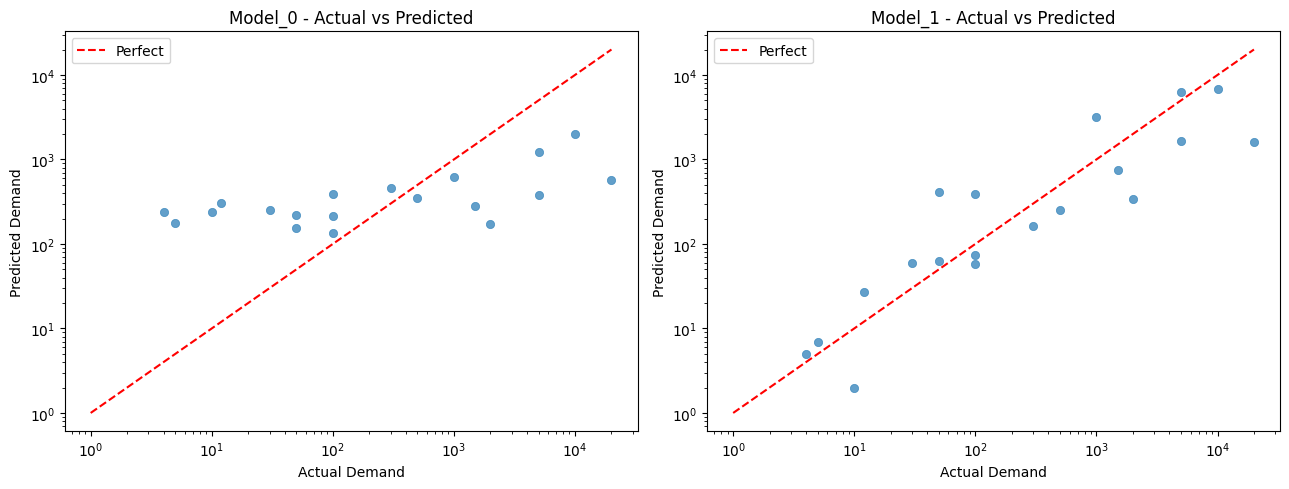

In [53]:
results = compare_models(model_0, model_1, X_cat_test, X_cont_test,
                         y_test, scaler_y=scaler_y, N=20, device=device)